# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/Users/mariajmelladot/Desktop/Frank2D/6_Frank2D_Oficial/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad

In [6]:
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [39]:
def f2d(data, N = 300):
    dir = "/Users/mariajmelladot/Desktop/Frank2D/data/uvtables/"
    disk_name = data['disk_name']
    data_file = dir +"uvtable_" + disk_name + "_continuum.npz"
    
    inc = data['inc']
    pa = data['pa']
    dra = data['dra']
    ddec = data['ddec']
    rout = data['rout']

    # Frank Parameters
    N = N
    
    # Load data
    file = np.load(data_file)
    u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
    Vis = Re + Im*1j
    
    uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

    dir_fits =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
    disk_fits = disk_name + '_continuum.fits'
    fits_file = dir_fits + disk_fits

    geom = Geometry(inc, pa, dra, ddec)
    frank2d = Frank2D(N, rout, geom)
    
    return frank2d, geom, uvtable, fits_file

# AS209

In [48]:
f2d_AS209, geom_AS209, uvtable_AS209, fits_1mm_AS209 = f2d(AS209)

### Run

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
   -> Kernel sparse matrix built in 3.49 seconds
--> time = 0.09  min |  5.25 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  39773051.282940544 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  30605898.285020255 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  31458951.244836483 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  32660086.132000692 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  32037725.273025826 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  68809248.88808323 vs  2

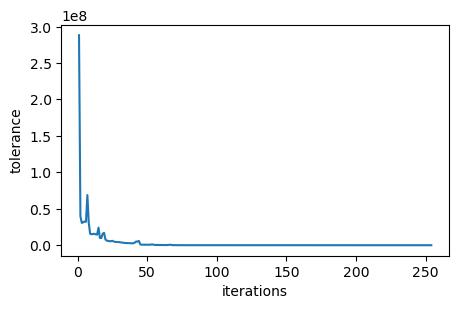

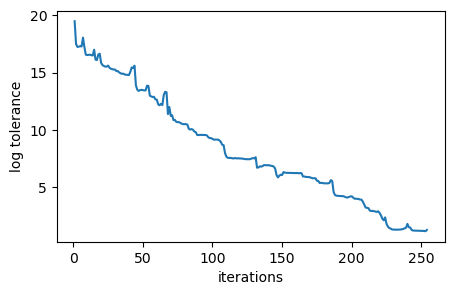

--> time = 0.25  min |  14.97 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...


In [9]:
#start_time = time.time()

params_AS209 =  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_AS209.fit( uvtable_AS209, 
              kernel_params = params_AS209, rtol = 1e-8 )

#end_time = time.time()
#print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

In [10]:
Plot_AS209 = Plot(f2d_AS209, geom_AS209)

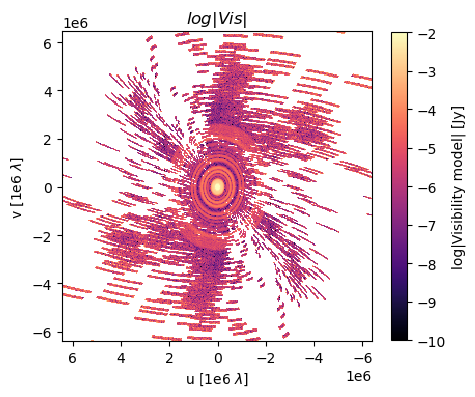

In [65]:
Plot_AS209.visibility(fig_size = 5, kind = 'input')

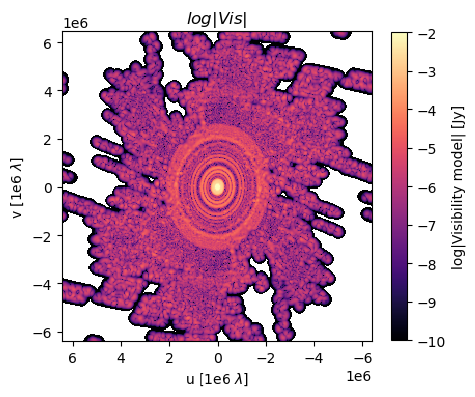

In [66]:
Plot_AS209.visibility(fig_size = 5)

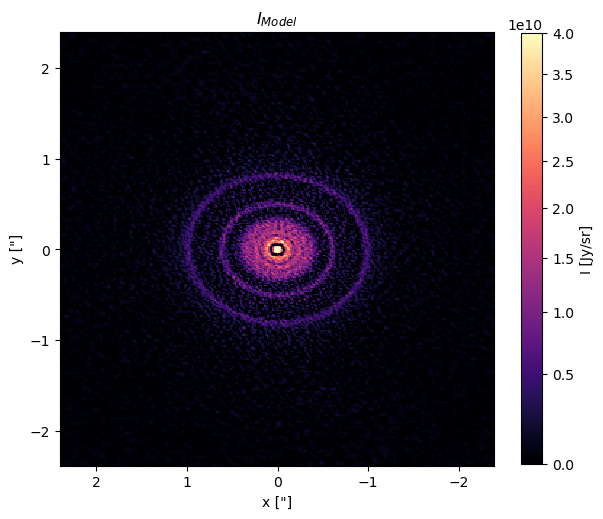

In [56]:
Plot_AS209.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

Performing 1D Frank fit...


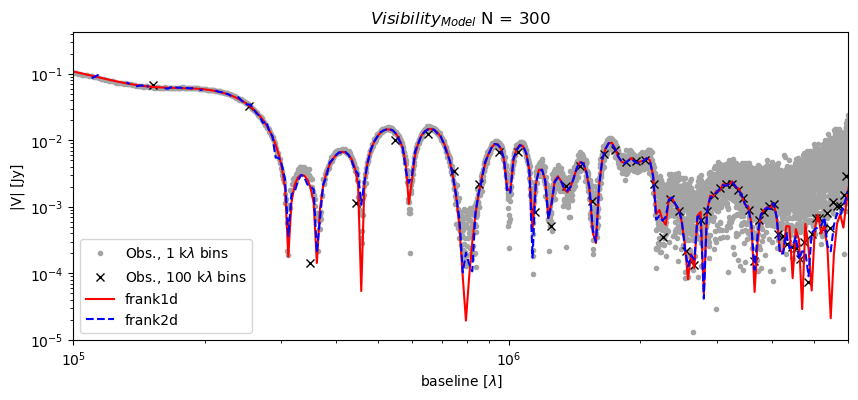

In [13]:
Plot_AS209.visibility_profile(input = uvtable_AS209, weighted = True, frank1d = True)

Performing 1D Frank fit...


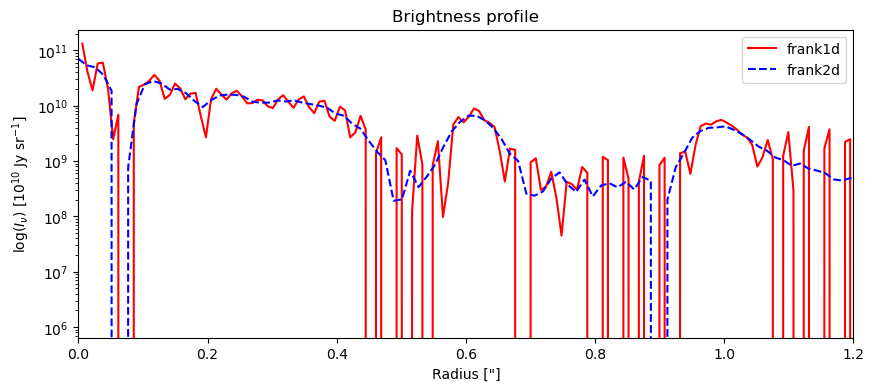

In [14]:
Plot_AS209.intensity_profile(clean = False, fits_file = fits_1mm_AS209)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


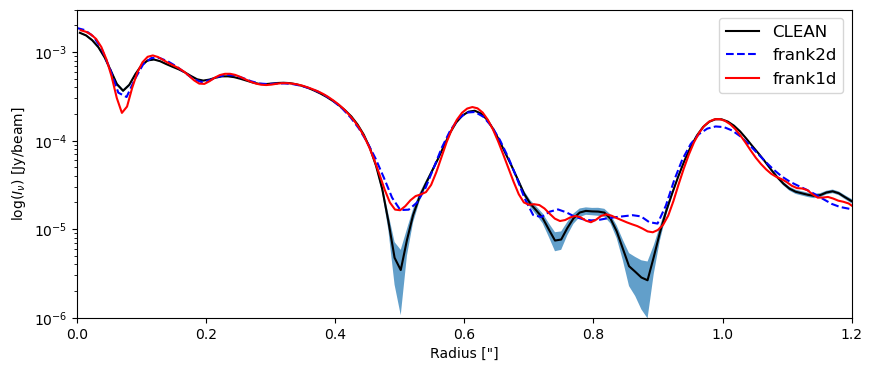

In [57]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

### Best

In [15]:
f2d_AS209.search_MAP()

Optimizing the posterior distribution...
-->  3.43 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -4868.31 (jDj=-2.978e+02, |S|=-1.003e+04, |D|=-4.003e-01)
-->  3.49 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -4868.31 (jDj=-2.978e+02, |S|=-1.003e+04, |D|=-4.003e-01)
-->  3.51 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -4620.15 (jDj=-2.185e+02, |S|=-9.459e+03, |D|=-3.171e-01)
-->  3.24 seconds for -logP(param|data) 
------> p: -2.162, m: -2.000, logc: 7.838197e+00, logl: 4.000000e+00: -5246.97 (jDj=-4.717e+02, |S|=-1.097e+04, |D|=-5.829e-01)
-->  3.13 seconds for -logP(param|data) 
------> p: -4.247, m: -2.000, logc: 5.752511e+00, logl: 4.000000e+00: 22016.02 (jDj=-6.693e+04, |S|=-2.297e+04, |D|=-6.948e+01)
-->  3.27 seconds for -logP(param|data) 
------> p: -2.958, m: -2.000, logc: 7.041536e+00, logl: 4.000000e+00: -60

In [62]:
best_AS209 = f2d_AS209.MAP
best_AS209

{'m': -1.3620942401288272, 'c': 4681.245509195992, 'l': 72454.18892316935}

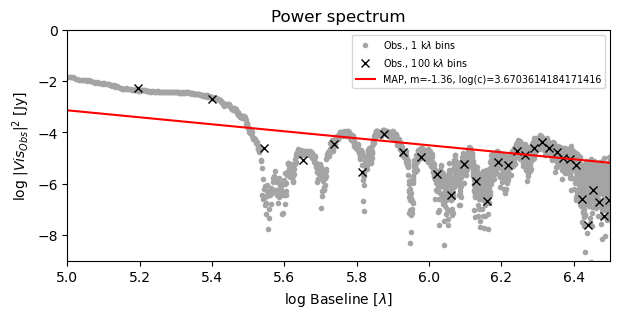

In [67]:
f2d_AS209.PP.plot_MAP_power_spectrum( uvtable_AS209['u'], uvtable_AS209['v'],
                                      uvtable_AS209['vis'], uvtable_AS209['weights'])

Setting GP Kernel Wendland...
Creating sparse linear system...
--> time = 0.10  min |  6.04 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 2.881751982790495
Final tolerance :  2.881751982790495
.... iteration:  0
                        -> actual tol:  288175198.2790495 vs  2.881751982790495
.... iteration:  1
                        -> actual tol:  26326029.400635004 vs  2.881751982790495
.... iteration:  2
                        -> actual tol:  23214280.628287163 vs  2.881751982790495
.... iteration:  3
                        -> actual tol:  23233701.207801204 vs  2.881751982790495
.... iteration:  4
                        -> actual tol:  23003288.59707105 vs  2.881751982790495
.... iteration:  5
                        -> actual tol:  22241997.23544606 vs  2.881751982790495
.... iteration:  6
                        -> actual tol:  23862398.663001567 vs  2.881751982790495
.... iteration:  7
                        -> actual tol:  23494428.4381

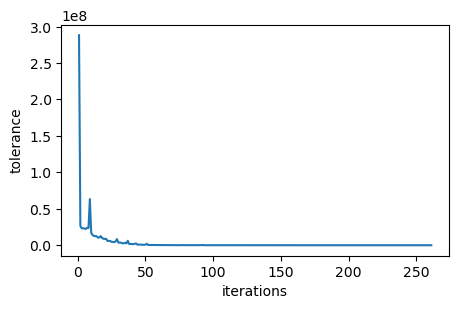

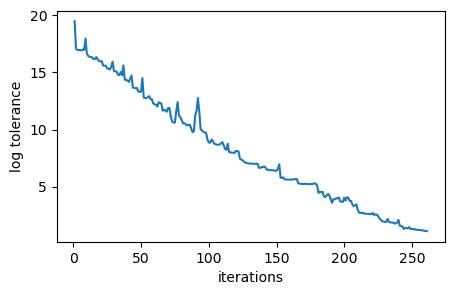

--> time = 0.19  min |  11.69 seconds
-> CGM converged?   True
-> Fit correctly?   True
!!!!  Sucess  !!!!
Building full visibility model...


In [30]:
f2d_AS209.fit(run_from_scratch = True, kernel_params = best_AS209, rtol = 1e-8)

In [52]:
Plot_AS209_2 = Plot(f2d_AS209, geom_AS209 )

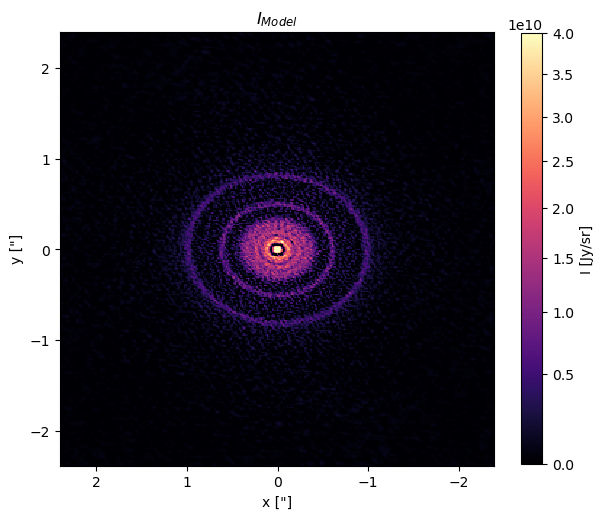

In [55]:
Plot_AS209_2.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


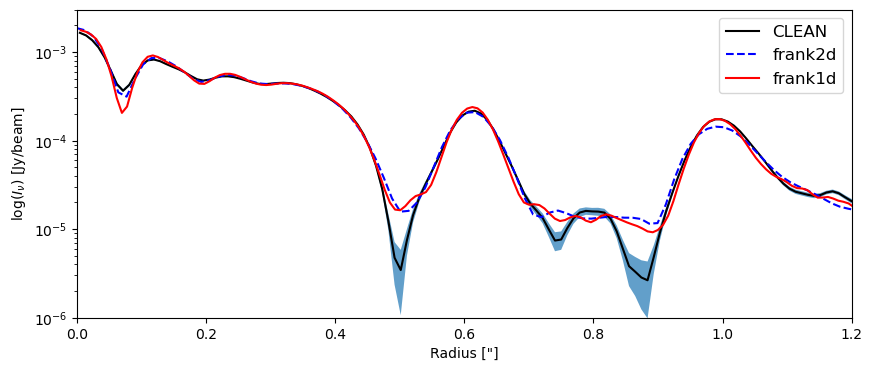

In [60]:
Plot_AS209_2.intensity_profile(clean = True, fits_file = fits_1mm_AS209)

Performing 1D Frank fit...


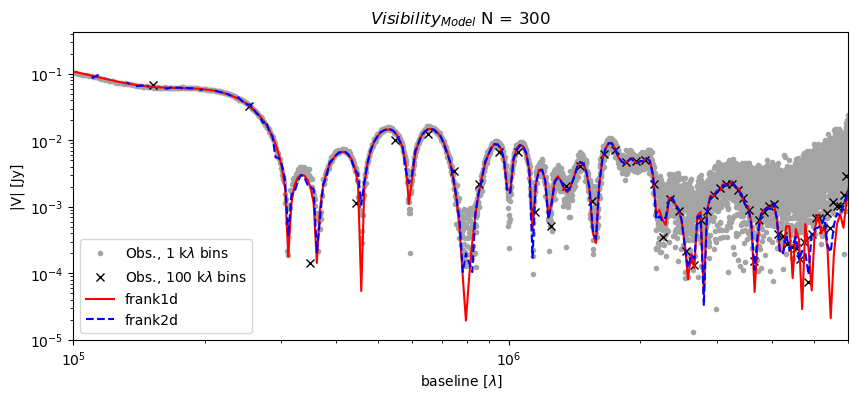

In [61]:
Plot_AS209_2.visibility_profile(input = uvtable_AS209, weighted = True, frank1d = True)

# Elias27

In [8]:
f2d_Elias27, geom_Elias27, uvtable_Elias27, fits_1mm_Elias27 = f2d(Elias27)

### Run

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.30  min |  17.70 seconds
--> time = 0.32  min |  18.99 seconds
Solving linear system...
         * rtol: 1e-07
         * final tolerance: 5.68501370369822
Final tolerance :  5.68501370369822
.... iteration:  0
                        -> actual tol:  56850137.03698221 vs  5.68501370369822
.... iteration:  1
                        -> actual tol:  12016552.687724585 vs  5.68501370369822
.... iteration:  2
                        -> actual tol:  42515826.873503774 vs  5.68501370369822
.... iteration:  3
                        -> actual tol:  46426794.592287615 vs  5.68501370369822
.... iteration:  4
                        -> actual tol:  9137285.906327771 vs  5.68501370369822
.... iteration:  5
                        -> actual tol:  4165213.0720396736 vs  5.68501370369822
.... iteration:  6
                        -> actual tol:  3583280.9057568535 vs  5.6850137036

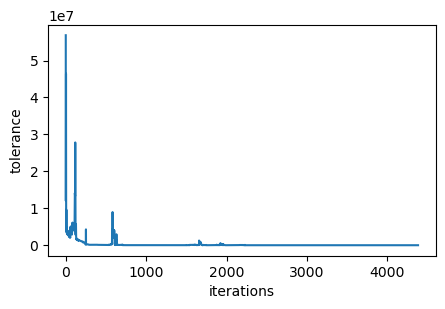

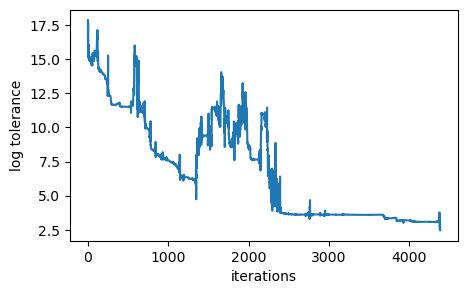

--> time = 42.19  min |  2531.61 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 43.28 minutes | 2596.66 seconds.


In [10]:
start_time = time.time()

params_Elias27 =  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_Elias27.fit( uvtable_Elias27,
                 kernel_params = params_Elias27, rtol = 1e-7 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot

In [16]:
Plot_Elias27 = Plot(f2d_Elias27, geom_Elias27)

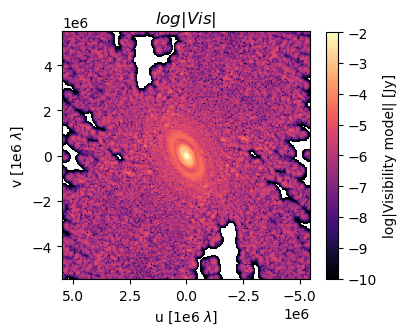

In [17]:
Plot_Elias27.visibility(fig_size = 4)

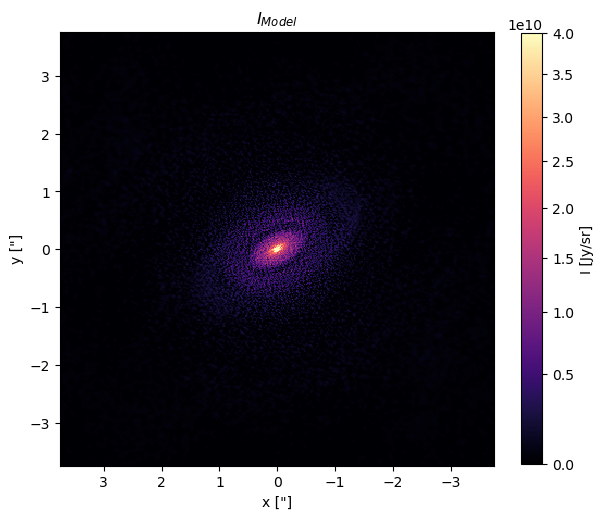

In [18]:
Plot_Elias27.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

### Best

In [25]:
f2d_Elias27.search_MAP()

Optimizing the posterior distribution...
-->  3.32 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3765.53 (jDj=-2.587e+02, |S|=-7.790e+03, |D|=-2.540e-01)
-->  3.12 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3765.53 (jDj=-2.587e+02, |S|=-7.790e+03, |D|=-2.540e-01)
-->  3.16 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -3511.69 (jDj=-1.908e+02, |S|=-7.214e+03, |D|=-2.001e-01)
-->  3.17 seconds for -logP(param|data) 
------> p: -2.162, m: -2.000, logc: 7.838197e+00, logl: 4.000000e+00: -4156.65 (jDj=-4.078e+02, |S|=-8.721e+03, |D|=-3.724e-01)
-->  3.17 seconds for -logP(param|data) 
------> p: -4.693, m: -2.000, logc: 5.307294e+00, logl: 4.000000e+00: 66895.62 (jDj=-1.570e+05, |S|=-2.329e+04, |D|=-1.244e+02)
-->  3.24 seconds for -logP(param|data) 
------> p: -3.129, m: -2.000, logc: 6.871478e+00, logl: 4.000000e+00: -49

In [29]:
best_Elias27 = f2d_Elias27.MAP
best_Elias27

NameError: name 'f2d_Elias27' is not defined

In [45]:
f2d_Elias27_2, _, _, _ = f2d(Elias27, N = 800)

In [46]:
best_Elias27 = {'m': -3.2974308124121103, 'c': 316116053366190.75, 'l': 44039.70624900817}

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.19  min |  11.11 seconds
--> time = 0.19  min |  11.65 seconds
Solving linear system...
         * rtol: 1e-07
         * final tolerance: 5.685109061791819
Final tolerance :  5.685109061791819
.... iteration:  0
                        -> actual tol:  56851090.61791819 vs  5.685109061791819
.... iteration:  1
                        -> actual tol:  21720052.663783688 vs  5.685109061791819
.... iteration:  2
                        -> actual tol:  4234434.361170658 vs  5.685109061791819
.... iteration:  3
                        -> actual tol:  3514721.477190735 vs  5.685109061791819
.... iteration:  4
                        -> actual tol:  3535664.6986828195 vs  5.685109061791819
.... iteration:  5
                        -> actual tol:  3074360.990913304 vs  5.685109061791819
.... iteration:  6
                        -> actual tol:  2888911.4180434057 vs  5.6851

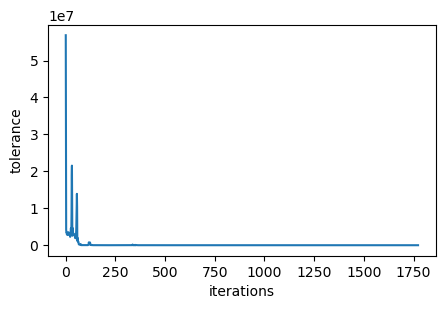

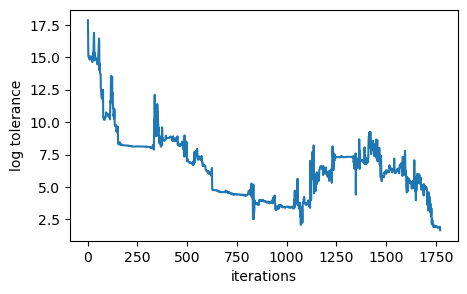

--> time = 10.15  min |  609.28 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 11.15 minutes | 669.18 seconds.


In [47]:
start_time = time.time()

f2d_Elias27_2.fit( uvtable_Elias27,
                   kernel_params = best_Elias27, rtol = 1e-7 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot best

In [50]:
Plot_Elias27_2 = Plot(f2d_Elias27_2, geom_Elias27)

In [51]:
len(Plot_Elias27_2.x_1d)

800

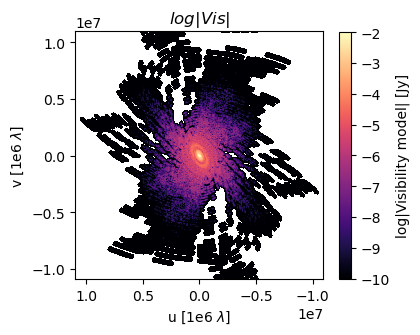

In [52]:
Plot_Elias27_2.visibility(fig_size = 4)

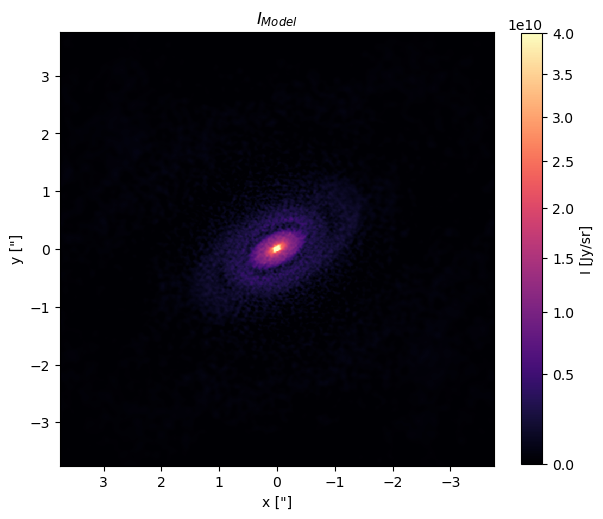

In [53]:
Plot_Elias27_2.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

In [40]:
Plot_Elias27_3 = Plot(f2d_Elias27, geom_Elias27)

In [41]:
Plot_Elias27_3._int_model = np.abs(Plot_Elias27_2._int_model - Plot_Elias27._int_model)

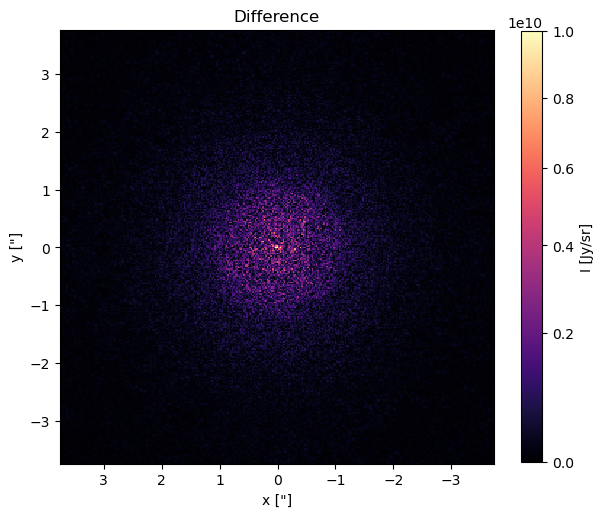

In [50]:
Plot_Elias27_3.intensity(fig_size = 7, title= r'difference', vmax = 1e10, gamma = 0.75, phase_shift = False)

# Elias24

In [ ]:
f2d_Elias24, geom_Elias24, uvtable_Elias24, fits_1mm_Elias24 = f2d(Elias24)

### Run

In [ ]:
start_time = time.time()

params_Elias24 =  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_Elias24.fit(u = uvtable_Elias24['u'], v = uvtable_Elias24['v'], Vis = uvtable_Elias24['vis'], Weights = uvtable_Elias24['weights'], 
                kernel_params = params_Elias24, rtol = 1e-8)

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot

In [ ]:
Plot_Elias24 = Plot(f2d_Elias24, geom_Elias24)

In [ ]:
Plot_Elias24.visibility(fig_size = 4)

In [ ]:
Plot_Elias24.intensity(fig_size = 5, vmax = 4e10, gamma = 0.75)

# IMLup

In [27]:
f2d_IMLup, geom_IMLup, uvtable_IMLup, fits_1mm_IMLup = f2d(IMLup)

### Run

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.24  min |  14.32 seconds
--> time = 0.25  min |  15.06 seconds
Solving linear system...
         * rtol: 1e-06
         * final tolerance: 136.12692421663124
Final tolerance :  136.12692421663124
.... iteration:  0
                        -> actual tol:  136126924.21663123 vs  136.12692421663124
.... iteration:  1
                        -> actual tol:  21923622.296686396 vs  136.12692421663124
.... iteration:  2
                        -> actual tol:  16484917.895498063 vs  136.12692421663124
.... iteration:  3
                        -> actual tol:  13860180.822889447 vs  136.12692421663124
.... iteration:  4
                        -> actual tol:  15033886.674490172 vs  136.12692421663124
.... iteration:  5
                        -> actual tol:  15573735.23205284 vs  136.12692421663124
.... iteration:  6
                        -> actual tol:  49757143.73454495 

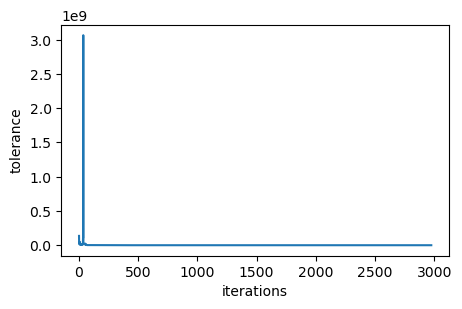

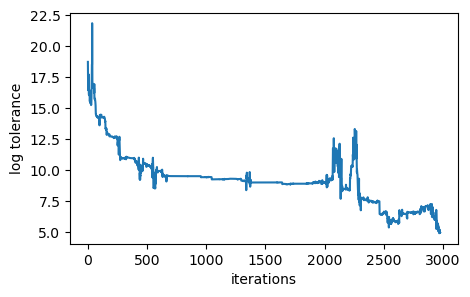

--> time = 19.27  min |  1156.01 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
F2D model in 20.16 minutes | 1209.56 seconds.


In [28]:
start_time = time.time()

params_IMLup =  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_IMLup.fit( uvtable_IMLup,
                kernel_params = params_IMLup, rtol = 1e-6 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot

In [10]:
Plot_IMLup = Plot(f2d_IMLup, geom_IMLup)

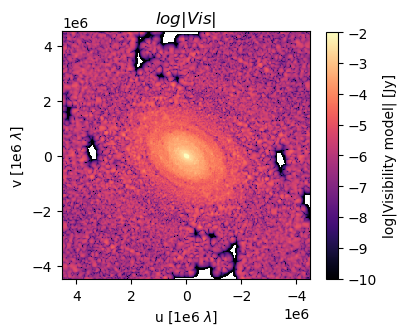

In [11]:
Plot_IMLup.visibility(fig_size = 4)

In [26]:
Plot_IMLup.intensity(fig_size = 7, vmax = 5e10, gamma = 0.75)

NameError: name 'Plot_IMLup' is not defined

### Best

In [13]:
f2d_IMLup.search_MAP()

Optimizing the posterior distribution...
-->  3.59 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3729.69 (jDj=-8.043e+02, |S|=-8.264e+03, |D|=-2.836e-01)
-->  3.54 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3729.69 (jDj=-8.043e+02, |S|=-8.264e+03, |D|=-2.836e-01)
-->  3.92 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -3536.64 (jDj=-6.148e+02, |S|=-7.688e+03, |D|=-2.238e-01)
-->  3.52 seconds for -logP(param|data) 
------> p: -2.162, m: -2.000, logc: 7.838197e+00, logl: 4.000000e+00: -3987.39 (jDj=-1.220e+03, |S|=-9.195e+03, |D|=-4.150e-01)
-->  3.35 seconds for -logP(param|data) 
------> p: -2.698, m: -2.000, logc: 7.302030e+00, logl: 4.000000e+00: -3901.60 (jDj=-4.477e+03, |S|=-1.228e+04, |D|=-1.444e+00)
-->  3.42 seconds for -logP(param|data) 
------> p: -2.367, m: -2.000, logc: 7.633399e+00, logl: 4.000000e+00: -41

IndexError: index 2 is out of bounds for axis 0 with size 2

# HD143006

In [14]:
f2d_HD143006, geom_HD143006, uvtable_HD143006, fits_1mm_HD143006= f2d(HD143006)

### Run

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.03  min |  2.03 seconds
--> time = 0.03  min |  2.08 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 1.2488686114852783
Final tolerance :  1.2488686114852783
.... iteration:  0
                        -> actual tol:  124886861.14852782 vs  1.2488686114852783
.... iteration:  1
                        -> actual tol:  23095932.883578066 vs  1.2488686114852783
.... iteration:  2
                        -> actual tol:  8385679.579926624 vs  1.2488686114852783
.... iteration:  3
                        -> actual tol:  7931247.0070678005 vs  1.2488686114852783
.... iteration:  4
                        -> actual tol:  5519733.039144919 vs  1.2488686114852783
.... iteration:  5
                        -> actual tol:  4729085.844281678 vs  1.2488686114852783
.... iteration:  6
                        -> actual tol:  3123789.944605709 vs  

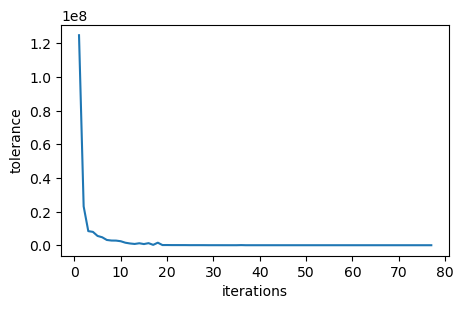

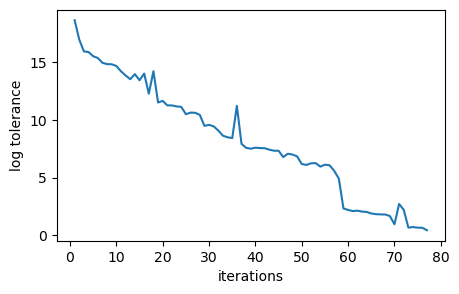

--> time = 0.03  min |  1.72 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 0.38 minutes | 22.93 seconds.


In [15]:
start_time = time.time()

params_HD143006 =  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_HD143006.fit(   uvtable_HD143006,
                    kernel_params = params_HD143006, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

In [16]:
Plot_HD143006 = Plot(f2d_HD143006, geom_HD143006)

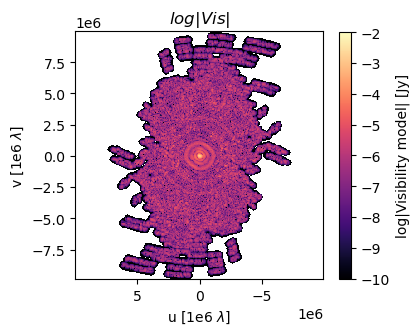

In [17]:
Plot_HD143006.visibility(fig_size = 4)

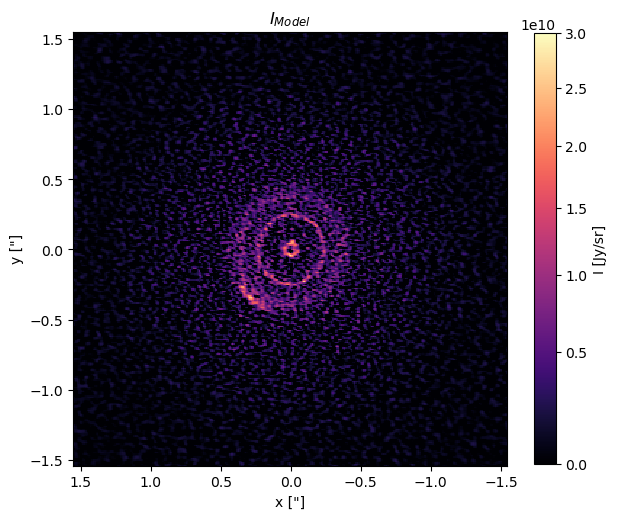

In [18]:
Plot_HD143006.intensity(fig_size = 7, vmax = 3e10, gamma = 0.75)

### Best

In [19]:
f2d_HD143006.search_MAP()

Optimizing the posterior distribution...
-->  5.24 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -6050.52 (jDj=-1.052e+02, |S|=-1.221e+04, |D|=-1.699e+00)
-->  5.01 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -6050.52 (jDj=-1.052e+02, |S|=-1.221e+04, |D|=-1.699e+00)
-->  4.93 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -5774.17 (jDj=-8.262e+01, |S|=-1.163e+04, |D|=-1.348e+00)
-->  4.81 seconds for -logP(param|data) 
------> p: -2.162, m: -2.000, logc: 7.838197e+00, logl: 4.000000e+00: -6491.05 (jDj=-1.548e+02, |S|=-1.314e+04, |D|=-2.469e+00)
-->  4.94 seconds for -logP(param|data) 
------> p: -10.803, m: -2.000, logc: -8.030081e-01, logl: 4.000000e+00: 11422244.03 (jDj=-2.288e+07, |S|=-6.288e+04, |D|=-3.074e+04)
-->  4.83 seconds for -logP(param|data) 
------> p: -5.462, m: -2.000, logc: 4.537550e+00, logl: 4.000000e+00

KeyboardInterrupt: 

# HD163296

In [ ]:
f2d_HD163296, geom_HD163296, uvtable_HD163296, fits_1mm_HD163296 = f2d(HD163296)

### Run

Shifted grid..
Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.08  min |  4.83 seconds
--> time = 0.08  min |  5.09 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 8.282981234488469
Final tolerance :  8.282981234488469
.... iteration:  0
                        -> actual tol:  828298123.4488468 vs  8.282981234488469
.... iteration:  1
                        -> actual tol:  167625301.17104715 vs  8.282981234488469
.... iteration:  2
                        -> actual tol:  167329104.60352567 vs  8.282981234488469
.... iteration:  3
                        -> actual tol:  166148073.285563 vs  8.282981234488469
.... iteration:  4
                        -> actual tol:  15579359483.92594 vs  8.282981234488469
.... iteration:  5
                        -> actual tol:  326003904.55865914 vs  8.282981234488469
.... iteration:  6
                        -> actual tol:  105573874.6405189 vs  8.2829812

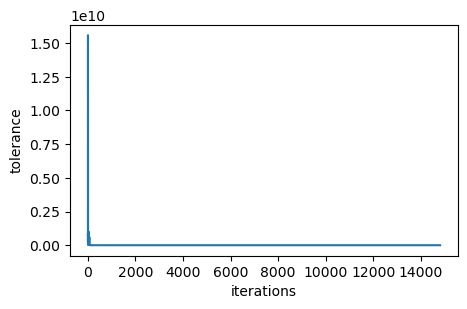

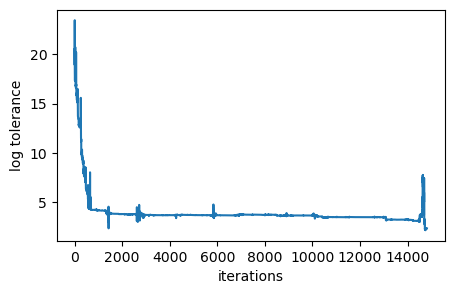

--> time = 21.88  min |  1312.66 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
F2D model in 22.27 minutes | 1336.45 seconds.


In [9]:
start_time = time.time()

params_HD163296=  {'m': -2, 'c': 1e8, 'l': 7e4}
f2d_HD163296.fit( uvtable_HD163296, kernel_params = params_HD163296, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time)/60:.2f} minutes | {(end_time - start_time):.2f} seconds.")

### Plot

In [10]:
Plot_HD163296 = Plot(f2d_HD163296, geom_HD163296)

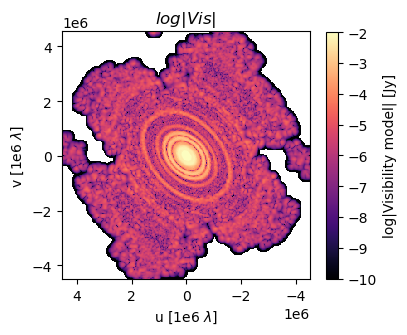

In [11]:
Plot_HD163296.visibility(fig_size = 4)

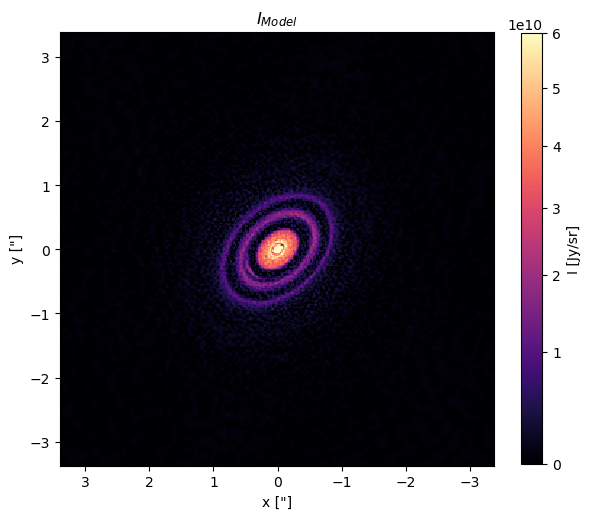

In [25]:
Plot_HD163296.intensity(fig_size = 7, vmax = 6e10, gamma = 0.75)

### Best

In [13]:
f2d_HD163296.search_MAP()

Optimizing the posterior distribution...
-->  4.94 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3076.19 (jDj=-2.140e+03, |S|=-8.293e+03, |D|=-3.716e-01)
-->  3.93 seconds for -logP(param|data) 
------> p: -2.000, m: -2.000, logc: 8.000000e+00, logl: 4.000000e+00: -3076.19 (jDj=-2.140e+03, |S|=-8.293e+03, |D|=-3.716e-01)
-->  4.14 seconds for -logP(param|data) 
------> p: -1.900, m: -2.000, logc: 8.100000e+00, logl: 4.000000e+00: -3116.03 (jDj=-1.485e+03, |S|=-7.718e+03, |D|=-2.934e-01)
-->  4.30 seconds for -logP(param|data) 
------> p: -1.738, m: -2.000, logc: 8.261803e+00, logl: 4.000000e+00: -3043.94 (jDj=-6.981e+02, |S|=-6.786e+03, |D|=-1.994e-01)
-->  4.13 seconds for -logP(param|data) 
------> p: -1.838, m: -2.000, logc: 8.161803e+00, logl: 4.000000e+00: -3106.01 (jDj=-1.150e+03, |S|=-7.362e+03, |D|=-2.533e-01)
-->  4.34 seconds for -logP(param|data) 
------> p: -1.938, m: -2.000, logc: 8.061803e+00, logl: 4.000000e+00: -31

KeyboardInterrupt: 